In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/sport_car_prices_cleaned.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663 entries, 0 to 662
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Car Make                         663 non-null    object 
 1   Car Model                        663 non-null    object 
 2   Year                             663 non-null    int64  
 3   Engine Size (L)                  663 non-null    float64
 4   Horsepower                       663 non-null    int64  
 5   Torque (lb-ft)                   663 non-null    int64  
 6   0-60 MPH Time (seconds)          663 non-null    float64
 7   Price (in thousands of dollars)  663 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 41.6+ KB


In [4]:
df.head()

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in thousands of dollars)
0,Porsche,911,2022,3.0,379,331,4.0,101.20
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,274.39
2,Ferrari,488 GTB,2022,3.9,661,561,3.0,333.75
3,Audi,R8,2022,5.2,562,406,3.2,142.70
4,McLaren,720S,2021,4.0,710,568,2.7,298.00


In [5]:
columns = {
    'Engine Size (L)': 'Engine Size',
    'Torque (lb-ft)': 'Torque',
    '0-60 MPH Time (seconds)': '0-60 MPH Time',
    'Price (in thousands of dollars)': 'Price'
}

In [6]:
df = df.rename(columns=columns)

In [7]:
df['Price'] = df['Price'] * 1000

In [8]:
df.head()

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,0-60 MPH Time,Price
0,Porsche,911,2022,3.0,379,331,4.0,101200.0
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,274390.0
2,Ferrari,488 GTB,2022,3.9,661,561,3.0,333750.0
3,Audi,R8,2022,5.2,562,406,3.2,142700.0
4,McLaren,720S,2021,4.0,710,568,2.7,298000.0


## Пояснение к Данным
    1. Car Make - марка машины
    2. Car Model - модель машиины
    3. Year - год машины
    4. Engine Size - обьем двигателя
    5. Horsepower - лошадиные силы
    6. Torque - сила и тяга мотора
    7. 0-60 MPH Time - разгон
    8. Price - цена (таргет)

## ВСЯ РАБОТА

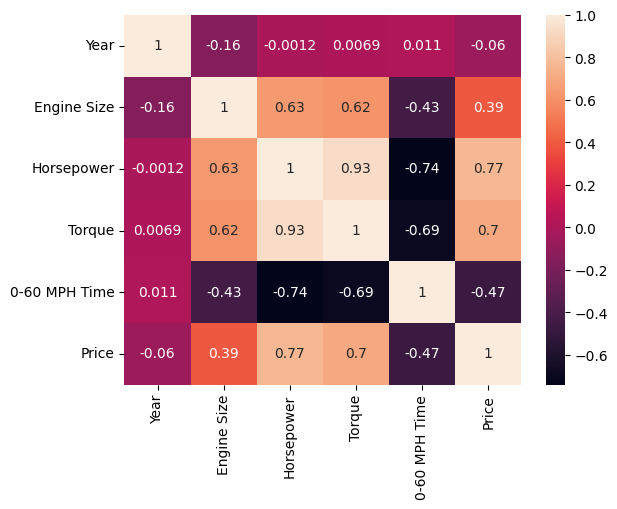

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True);

<Axes: xlabel='Price', ylabel='Count'>

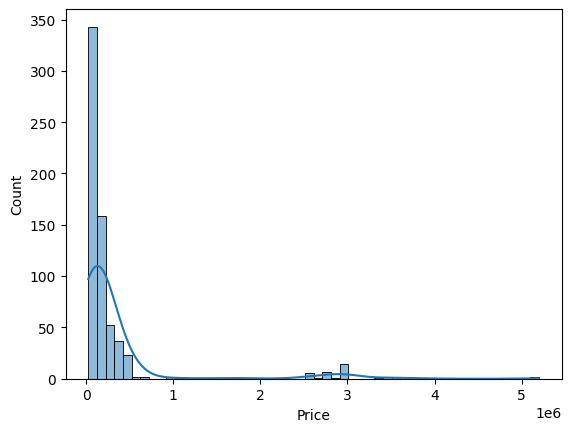

In [10]:
sns.histplot(df['Price'], kde=True)

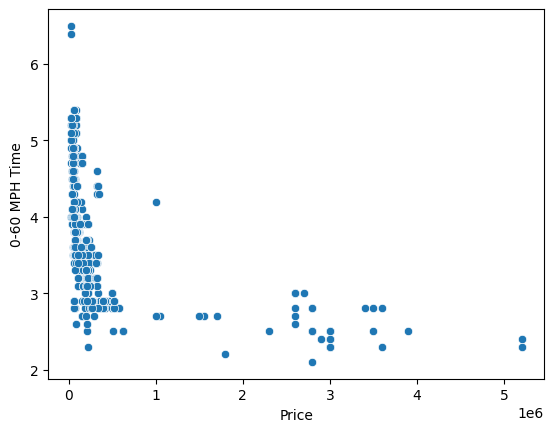

In [11]:
sns.scatterplot(x='Price', y='0-60 MPH Time', data=df);

In [12]:
df[df['0-60 MPH Time'] > 6]

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,0-60 MPH Time,Price
86,Mazda,MX-5 Miata,2021,2.0,181,151,6.5,26830.0
502,Dodge,Challenger,2022,3.6,305,268,6.4,28000.0


In [13]:
df = df.drop([86, 502])

In [14]:
df[df['Price'] > 5_000_000]

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,0-60 MPH Time,Price
412,Bugatti,Chiron Super Sport 300+,2022,8.0,1578,1180,2.3,5200000.0
568,Bugatti,Chiron Super Sport 300+,2021,8.0,1578,1180,2.4,5200000.0


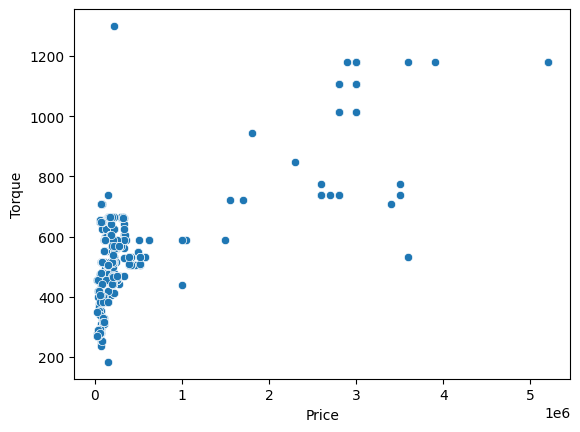

In [15]:
sns.scatterplot(x='Price', y='Torque', data=df);

In [16]:
df[df['Torque'] > 1200]

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,0-60 MPH Time,Price
400,Ultima,RS,2021,6.2,1200,1300,2.3,220000.0


In [17]:
df = df.drop(400)

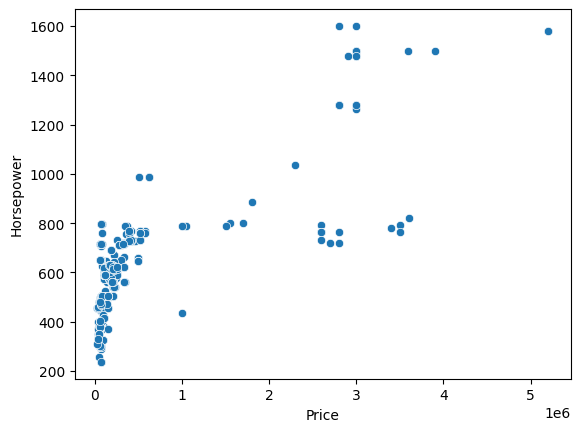

In [18]:
sns.scatterplot(x='Price', y='Horsepower', data=df);

In [19]:
df[(df['Horsepower'] > 900) & (df['Price'] < 1_000_000)]

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,0-60 MPH Time,Price
28,Ferrari,SF90 Stradale,2021,4.0,986,590,2.5,625000.0
154,Ferrari,SF90 Stradale,2022,4.0,986,590,2.5,507000.0
216,Ferrari,SF90 Stradale,2022,4.0,986,590,2.5,625000.0


In [20]:
df[(df['Horsepower'] < 500) & (df['Price'] > 900_000)]

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,0-60 MPH Time,Price
148,Shelby,Cobra,1965,7.0,435,440,4.2,1000000.0


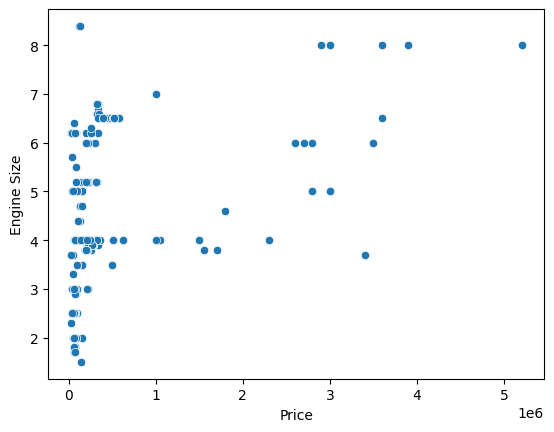

In [21]:
sns.scatterplot(x='Price', y='Engine Size', data=df);

In [22]:
df[df['Engine Size'] > 8]

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,0-60 MPH Time,Price
140,Dodge,Viper,2017,8.4,645,600,3.3,120000.0
296,Dodge,Viper,2017,8.4,645,600,3.3,118795.0
317,Dodge,Viper ACR,2017,8.4,645,600,3.3,126190.0


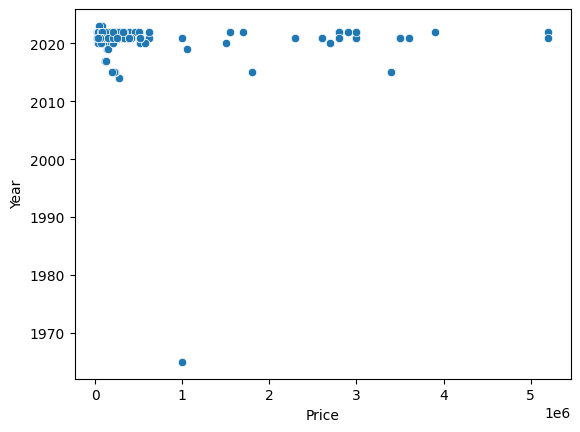

In [23]:
sns.scatterplot(x='Price', y='Year', data=df);

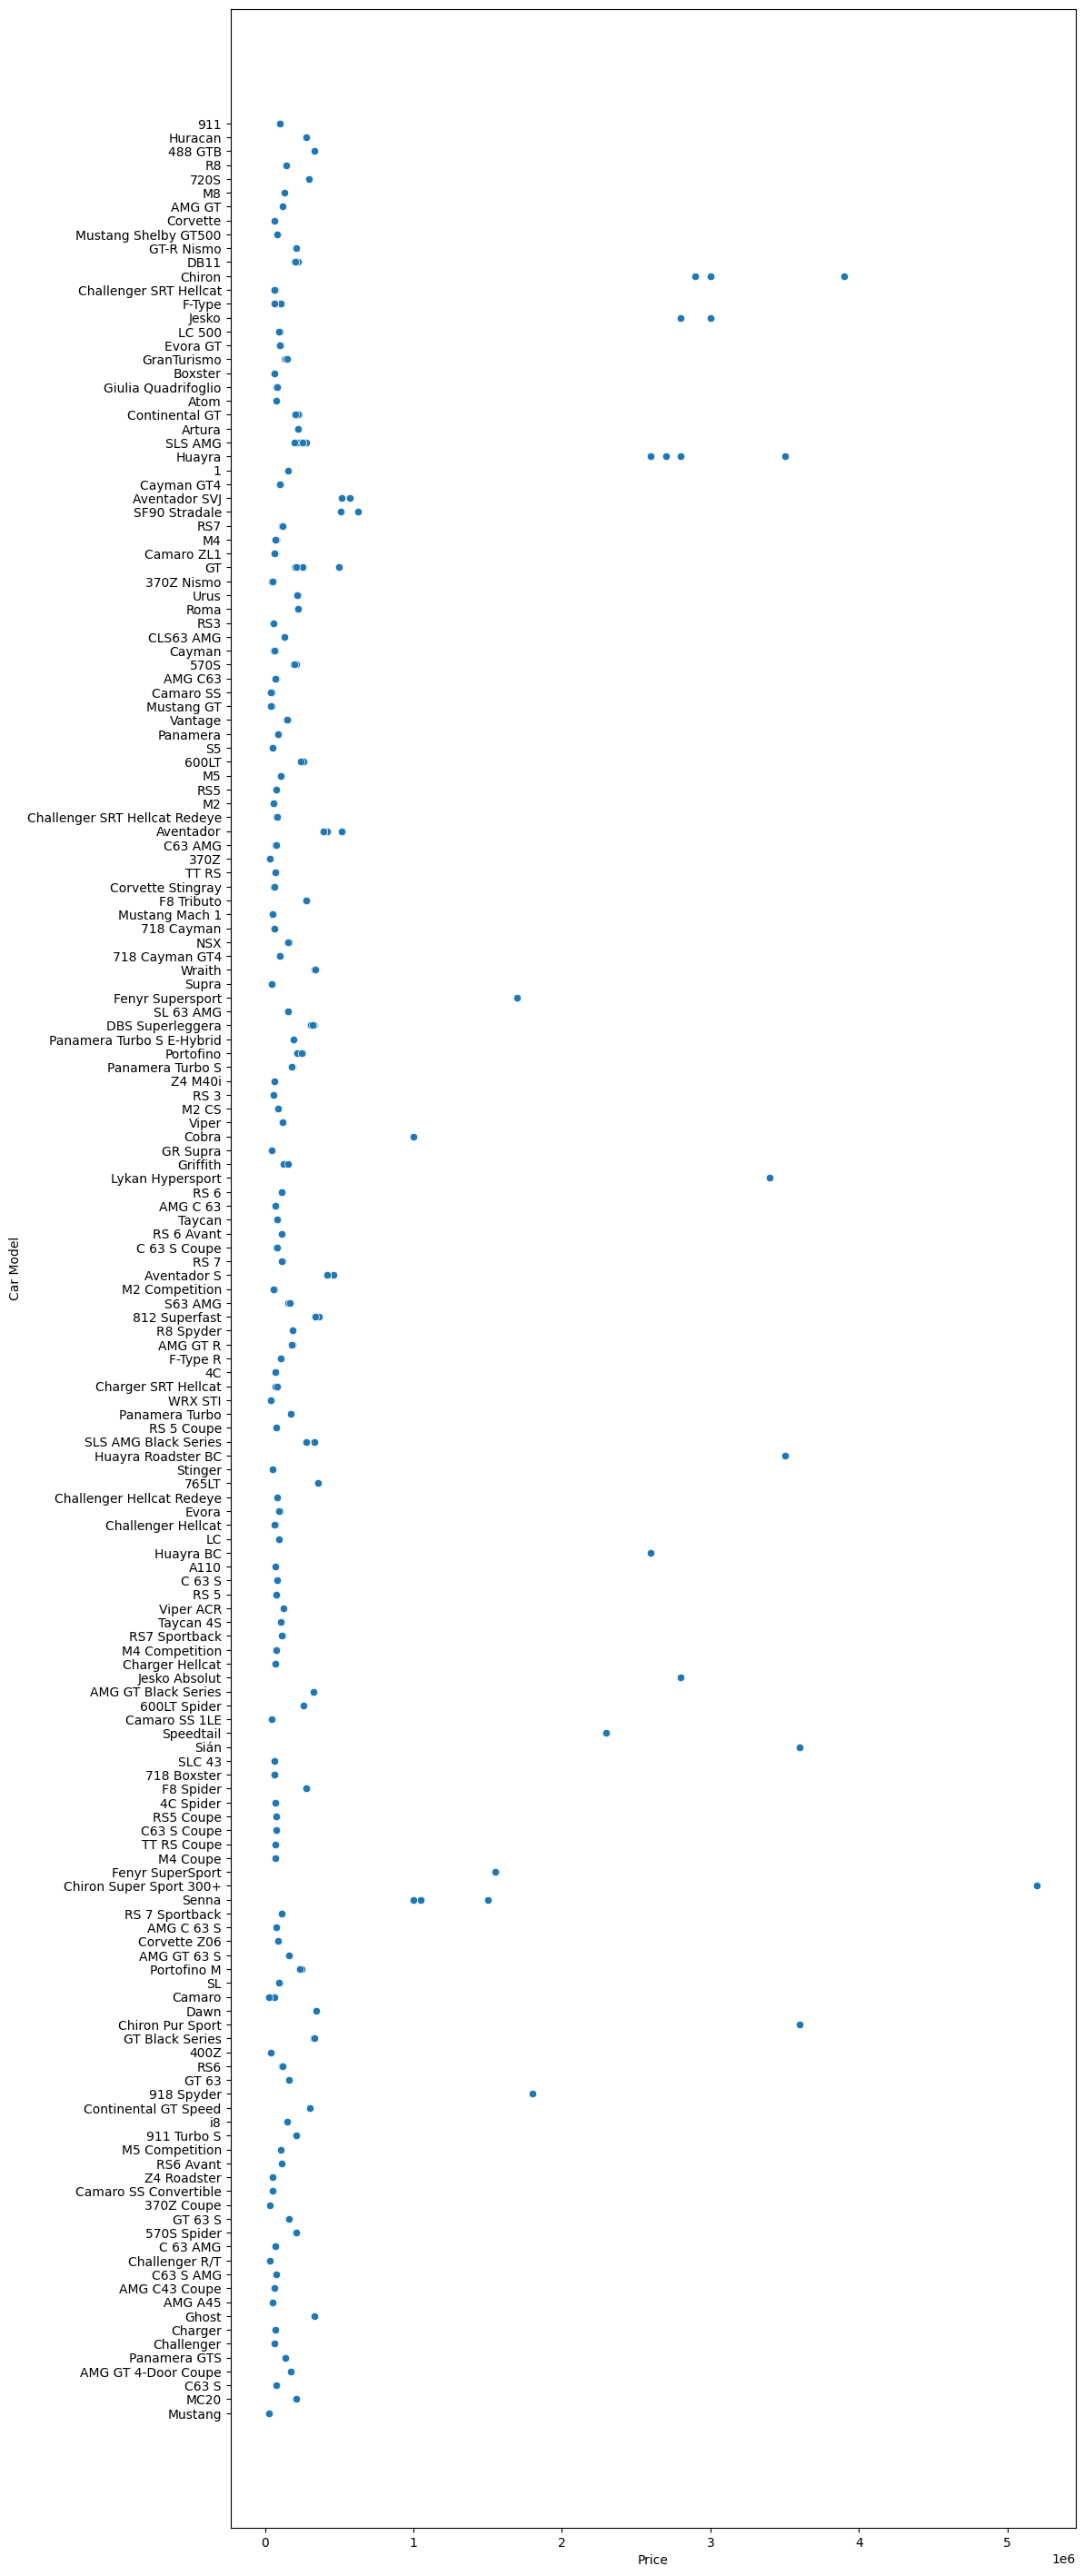

In [24]:
plt.figure(figsize=(12, 36))
sns.scatterplot(x='Price', y='Car Model', data=df);

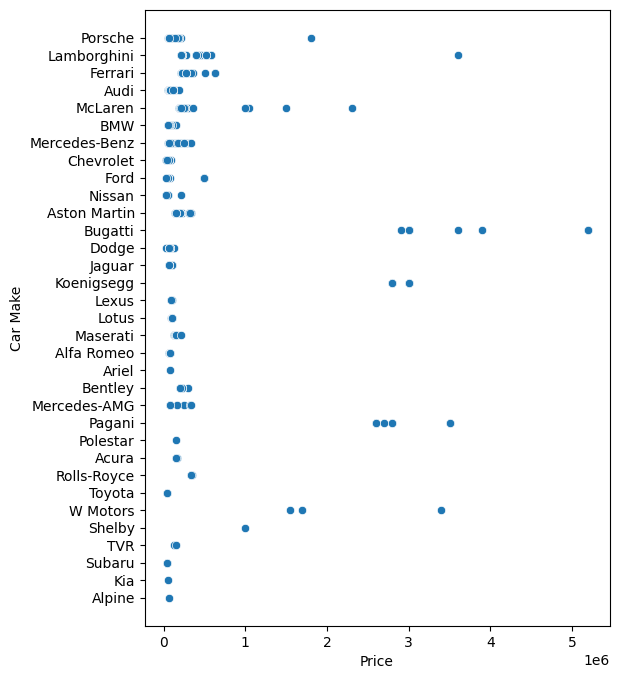

In [25]:
plt.figure(figsize=(6, 8))
sns.scatterplot(x='Price', y='Car Make', data=df);

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import KNNImputer

In [27]:
X = df.drop('Price', axis=1)

In [28]:
y = df['Price']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [30]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [31]:
num_features

['Year', 'Engine Size', 'Horsepower', 'Torque', '0-60 MPH Time']

In [32]:
cat_features

['Car Make', 'Car Model']

In [33]:
num_transformer = Pipeline([
    ('scaler', StandardScaler())
])

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', num_transformer, num_features)
    ]
)

In [35]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', ElasticNetCV(cv=10, l1_ratio=[1.0], n_jobs=-1, max_iter=100_000))
])

In [36]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [37]:
y_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)

In [38]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 3885.5686983251285
Лучшее значение l1_ratio: 1.0


In [39]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

In [40]:
MAE

64298.48921764583

In [41]:
MSE

8939941387.335165

In [42]:
RMSE

np.float64(94551.26327730986)

In [43]:
r2_train

0.961107257418966

In [44]:
r2_test

0.9718931981561503

In [45]:
df['Price'].mean()

np.float64(337218.7833333333)

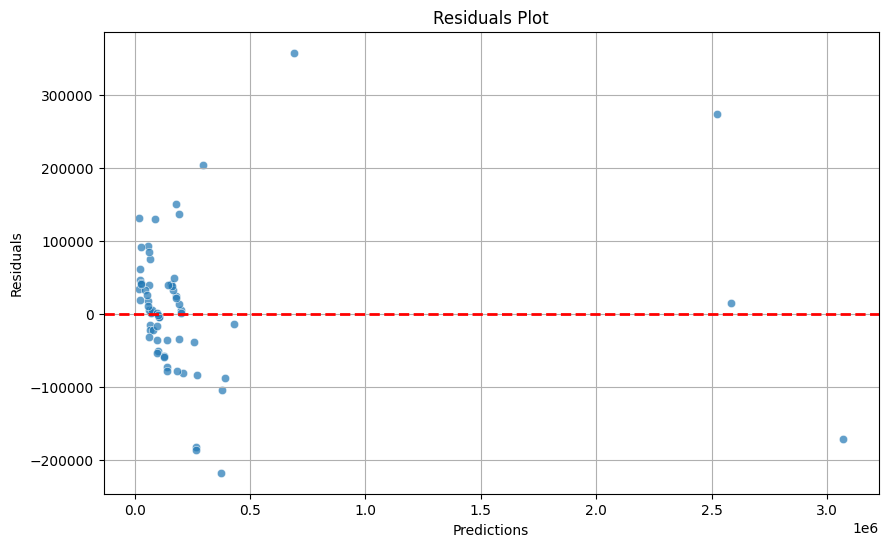

In [46]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

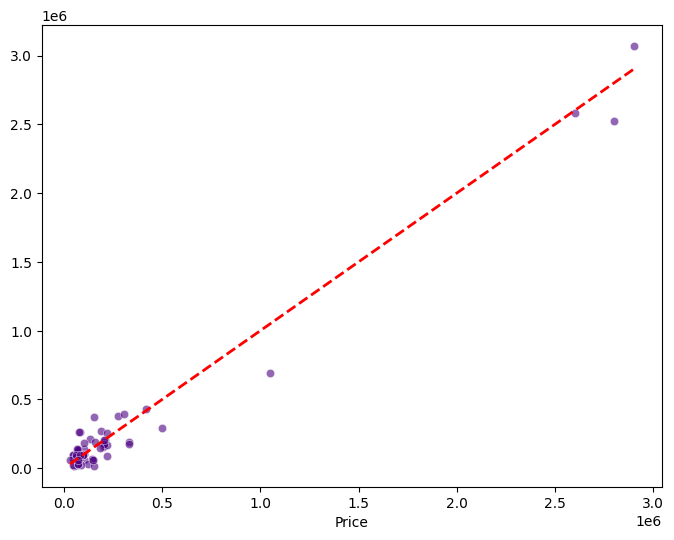

In [47]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='indigo')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2);

In [48]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [49]:
y_pred_full = pipe.predict(X)

In [50]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 1656.8714138366765
Лучшее значение l1_ratio: 1.0


In [51]:
r2_full = r2_score(y, y_pred_full)

In [52]:
r2_full

0.9810512098340867

In [53]:
df['Car Model'].unique()

array(['911', 'Huracan', '488 GTB', 'R8', '720S', 'M8', 'AMG GT',
       'Corvette', 'Mustang Shelby GT500', 'GT-R Nismo', 'DB11', 'Chiron',
       'Challenger SRT Hellcat', 'F-Type', 'Jesko', 'LC 500', 'Evora GT',
       'GranTurismo', 'Boxster', 'Giulia Quadrifoglio', 'Atom',
       'Continental GT', 'Artura', 'SLS AMG', 'Huayra', '1', 'Cayman GT4',
       'Aventador SVJ', 'SF90 Stradale', 'RS7', 'M4', 'Camaro ZL1', 'GT',
       '370Z Nismo', 'Urus', 'Roma', 'RS3', 'CLS63 AMG', 'Cayman', '570S',
       'AMG C63', 'Camaro SS', 'Mustang GT', 'Vantage', 'Panamera', 'S5',
       '600LT', 'M5', 'RS5', 'M2', 'Challenger SRT Hellcat Redeye',
       'Aventador', 'C63 AMG', '370Z', 'TT RS', 'Corvette Stingray',
       'F8 Tributo', 'Mustang Mach 1', '718 Cayman', 'NSX',
       '718 Cayman GT4', 'Wraith', 'Supra', 'Fenyr Supersport',
       'SL 63 AMG', 'DBS Superleggera', 'Panamera Turbo S E-Hybrid',
       'Portofino', 'Panamera Turbo S', 'Z4 M40i', 'RS 3', 'M2 CS',
       'Viper', 'Cobra', 

In [54]:
test_sportcars = pd.DataFrame(
    [
        {
            "Car Make": "Porsche",
            "Car Model": "918 Spyder",
            "Year": 2022,
            "Engine Size": 4.6,
            "Horsepower": 887,
            "Torque": 944,
            "0-60 MPH Time": 2.2,
        },
        {
            "Car Make": "Bugatti",
            "Car Model": "Chiron",
            "Year": 2021,
            "Engine Size": 8.0,
            "Horsepower": 1500,
            "Torque": 1180,
            "0-60 MPH Time": 2.5,
        },
    ]
)

In [55]:
test_sportcars

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,0-60 MPH Time
0,Porsche,918 Spyder,2022,4.6,887,944,2.2
1,Bugatti,Chiron,2021,8.0,1500,1180,2.5


In [56]:
preds = pipe.predict(test_sportcars)

In [57]:
print(f"1. Предсказанная цена Porsche 918 Spyder: {preds[0]:,.2f} $")
print(f"2. Предсказанная цена гиперкара Bugatti Chiron: {preds[1]:,.2f} $")

1. Предсказанная цена Porsche 918 Spyder: 1,091,315.34 $
2. Предсказанная цена гиперкара Bugatti Chiron: 3,112,032.50 $


In [58]:
nissan = pd.DataFrame(
        {
            "Car Make": ["Nissan"],
            "Car Model": ['GT-R Nismo'],
            "Year": [2021],
            "Engine Size": [3.8],
            "Horsepower": [600],
            "Torque": [481],
            "0-60 MPH Time": [2.5],
        }
)

In [59]:
print(f"1. Предсказанная цена Nissan GT-R Nismo: {float(pipe.predict(nissan)[0]):,.2f} $")

1. Предсказанная цена Nissan GT-R Nismo: 299,895.11 $


In [60]:
import json
import os

advanced_report = {
    "project": "Elite Sports Car Price Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_Elite_Sports_Car_Prices": df['Price'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [61]:
from joblib import dump, load

In [62]:
dump(pipe, 'model/elite_sports_cars_price_predict_elastic_net_cv_2026_v1.pkl')

['model/elite_sports_cars_price_predict_elastic_net_cv_2026_v1.pkl']

In [63]:
loaded_pipe = load('model/elite_sports_cars_price_predict_elastic_net_cv_2026_v1.pkl')

In [64]:
print(f"1. Предсказанная цена Nissan GT-R Nismo: {float(loaded_pipe.predict(nissan)[0]):,.2f} $")

1. Предсказанная цена Nissan GT-R Nismo: 299,895.11 $
